# Expectation Decider – Probability & Statistics
This notebook solves the assignment step by step using a generated dataset of 200 students.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import comb

pd.set_option('display.max_columns', None)
df = pd.read_csv('expectation_decider_dataset.csv')
df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,14.0,82.3,Yes,70,Pass
1,11.4,84.7,Yes,59,Pass
2,14.6,91.0,Yes,58,Pass
3,18.1,90.6,No,59,Fail
4,11.1,61.5,No,71,Fail


## 1. Understanding the Basics
**Probability** is the numerical chance that an event will happen.

Examples from this dataset:
1. Probability that a randomly selected student passes.
2. Probability that a student studies more than 10 hours per week.
3. Probability that a student participates in group discussion.

In [2]:
n = len(df)
p_pass = (df['final_exam_pass'] == 'Pass').mean()
p_study_above_10 = (df['study_hours'] > 10).mean()
p_group_yes = (df['group_discussion'] == 'Yes').mean()
print('P(Pass) =', p_pass)
print('P(Study hours > 10) =', p_study_above_10)
print('P(Group discussion = Yes) =', p_group_yes)

P(Pass) = 0.495
P(Study hours > 10) = 0.685
P(Group discussion = Yes) = 0.605


## 2. Empirical and Theoretical Probability
**Empirical probability** is calculated from observed data.

**Theoretical probability** is calculated using a mathematical model. For 3 independent selections where the probability of passing is `p`, the number of passes follows a binomial distribution.

In [3]:
empirical_probability = (df['final_exam_pass'] == 'Pass').mean()
print('Empirical probability of passing =', empirical_probability)

p = empirical_probability
k = 2
n_trials = 3
theoretical_probability_exactly_2 = comb(n_trials, k) * (p ** k) * ((1-p) ** (n_trials-k))
print('Theoretical/model probability of exactly 2 passes out of 3 =', theoretical_probability_exactly_2)

Empirical probability of passing = 0.495
Theoretical/model probability of exactly 2 passes out of 3 = 0.37121287499999994


## 3. Random Variable and Probability Distribution
Let **X = number of students passing among 3 randomly selected students**.

X can take values 0, 1, 2, or 3. We use the binomial model with `p = P(Pass)`.

In [4]:
x_values = np.arange(0, 4)
probabilities = [comb(3, x) * p**x * (1-p)**(3-x) for x in x_values]
dist = pd.DataFrame({'X': x_values, 'P(X)': probabilities})
print(dist)
mean_x = 3 * p
variance_x = 3 * p * (1-p)
print('Mean =', mean_x)
print('Variance =', variance_x)

   X      P(X)
0  0  0.128788
1  1  0.378712
2  2  0.371213
3  3  0.121287
Mean = 1.4849999999999999
Variance = 0.749925


## 4. Venn Diagram Conditions
A = students who study more than 10 hours/week.

B = students whose attendance is greater than 80%.

The overlap A ∩ B contains students satisfying both conditions.

A only          69
B only          25
Both (A ∩ B)    68
Neither         38
dtype: int64


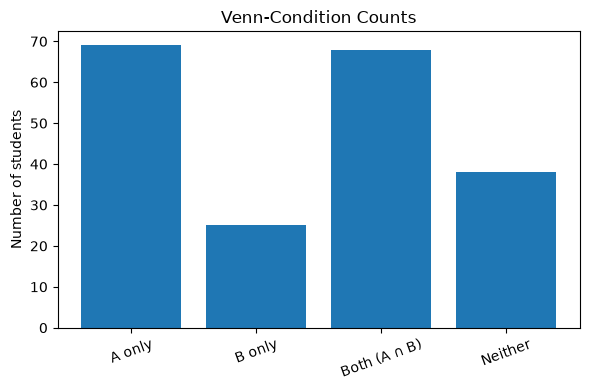

In [5]:
A = df['study_hours'] > 10
B = df['attendance'] > 80
counts = {
    'A only': (A & ~B).sum(),
    'B only': (~A & B).sum(),
    'Both (A ∩ B)': (A & B).sum(),
    'Neither': (~A & ~B).sum()
}
print(pd.Series(counts))

plt.figure(figsize=(6,4))
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=20)
plt.ylabel('Number of students')
plt.title('Venn-Condition Counts')
plt.tight_layout()
plt.show()

## 5. Contingency Table and Probability Calculations

In [6]:
table = pd.crosstab(df['group_discussion'], df['final_exam_pass'])
print(table)

total = len(df)
joint_probability = ((df['group_discussion'] == 'Yes') & (df['final_exam_pass'] == 'Pass')).mean()
marginal_probability_pass = (df['final_exam_pass'] == 'Pass').mean()
conditional_probability = (
    ((df['group_discussion'] == 'Yes') & (df['final_exam_pass'] == 'Pass')).sum()
    / (df['group_discussion'] == 'Yes').sum()
)
print('Joint P(Group discussion Yes AND Pass) =', joint_probability)
print('Marginal P(Pass) =', marginal_probability_pass)
print('Conditional P(Pass | Group discussion Yes) =', conditional_probability)

final_exam_pass   Fail  Pass
group_discussion            
No                  47    32
Yes                 54    67
Joint P(Group discussion Yes AND Pass) = 0.335
Marginal P(Pass) = 0.495
Conditional P(Pass | Group discussion Yes) = 0.5537190082644629


## 6. Conditional Probability and Independence
If P(Pass | Group discussion = Yes) is different from P(Pass), the two events are not independent.

They are not mutually exclusive because a student can participate in group discussion and pass the exam at the same time.

In [7]:
p_pass_given_yes = conditional_probability
print('P(Pass | Yes) =', p_pass_given_yes)
print('P(Pass) =', marginal_probability_pass)
print('Independent?', np.isclose(p_pass_given_yes, marginal_probability_pass))

P(Pass | Yes) = 0.5537190082644629
P(Pass) = 0.495
Independent? False


## 7. Bayes Theorem
Given:
- P(High attendance | Pass) = 0.70
- P(High attendance | Fail) = 0.40
- P(High attendance) = 0.60

Using Bayes theorem:
P(Pass | High attendance) = P(High attendance | Pass) × P(Pass) / P(High attendance)

The assignment does not explicitly provide P(Pass), so we estimate it from the dataset.

In [8]:
p_high_given_pass = 0.70
p_high_given_fail = 0.40
p_high = 0.60
p_pass_dataset = (df['final_exam_pass'] == 'Pass').mean()
bayes_result = (p_high_given_pass * p_pass_dataset) / p_high
print('Estimated P(Pass | High attendance) =', bayes_result)

Estimated P(Pass | High attendance) = 0.5775


## Final Summary
The analysis compares study hours, attendance, group discussion, and previous test scores with exam outcomes. The generated dataset is illustrative; results depend on the random seed and should not be interpreted as real educational evidence.